In [ ]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=cde9209eabf6600fb79aa65dc82f9d3cbde3f505fad1799f2b4bb9b7cc458a7b
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings("ignore")

import os
import re
import csv
import math
import json
import random
import unicodedata

from ast import literal_eval
from datasets import Dataset, DatasetDict

from matplotlib import cm
from wordcloud import WordCloud
import networkx as nx
import community as community_louvain

from tqdm.auto import tqdm
import collections
from collections import Counter, defaultdict
import itertools

from scipy import stats
from scipy.stats import wasserstein_distance, entropy,f_oneway, kruskal

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from sklearn.utils import resample
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score


In [ ]:
!pip show datasets

Name: datasets
Version: 4.0.0
Summary: HuggingFace community-driven open-source library of datasets
Home-page: https://github.com/huggingface/datasets
Author: HuggingFace Inc.
Author-email: thomas@huggingface.co
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: dill, filelock, fsspec, huggingface-hub, multiprocess, numpy, packaging, pandas, pyarrow, pyyaml, requests, tqdm, xxhash
Required-by: torchtune


In [ ]:
#Dataset loading
!pip install datasets==2.14.5
from datasets import load_dataset

# Load the dataset directly using the dataset name and configuration
ds = load_dataset("ai4bharat/naamapadam", "or") # "te" for telugu, "as" for assamese, "ta" -->tamil, "hi" -->hindi, "mr" -->Marathi, "kn" -->Kannada, "or" -->Oriya, "pa" -->Punjabi
print(ds)
print(ds["train"][0])

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
  Attempting uninstall: datasets
    Foun

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 196793
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 994
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 993
    })
})
{'tokens': ['ଅଥଚ', 'ବଡ଼ଚଣାର', 'କଂଗ୍ରେସ', 'ପ୍ରାର୍ଥୀ', 'ଆଜି', 'ପର୍ଯ୍ୟନ୍ତ', 'ଘୋଷଣା', 'କରାଯାଇପାରି', 'ନାହିଁ', '।'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [ ]:
print(ds["train"].features)
print(f"Total no. of data points: {len(ds['train']['tokens'])}")


{'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'ner_tags': Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)}
Total no. of data points: 196793


In [ ]:
print(ds["train"][1])

{'tokens': ['ମୋଦିଙ୍କୁ', 'ଆକ୍ଷେପ', 'କରି', 'ଗଡକରି', 'ଏହା', 'କହିଛନ୍ତି', '।'], 'ner_tags': [0, 1, 0, 0, 0, 0, 0]}


# Task
Perform extensive exploratory data analysis (EDA) on the provided dataset, focusing on the 'tokens' and 'ner_tags' features. Analyze the distribution of NER tags, sentence lengths, and the relationship between them. Identify the most frequent tokens overall and for each NER tag. Finally, provide a summary of the key insights gained from the analysis.

## Explore the dataset structure and content

### Subtask:
Understand the format of the data, including the 'tokens' and 'ner_tags' features.


**Reasoning**:
The first three steps of the subtask involve printing information about the dataset structure, the first example, and the features. These can all be done in a single code block.



In [ ]:
print(ds)
print(ds["train"][0])
print(ds["train"].features)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 196793
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 994
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 993
    })
})
{'tokens': ['ଅଥଚ', 'ବଡ଼ଚଣାର', 'କଂଗ୍ରେସ', 'ପ୍ରାର୍ଥୀ', 'ଆଜି', 'ପର୍ଯ୍ୟନ୍ତ', 'ଘୋଷଣା', 'କରାଯାଇପାରି', 'ନାହିଁ', '।'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
{'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'ner_tags': Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)}


## Analyze the distribution of ner tags

### Subtask:
Calculate and visualize the frequency of each named entity recognition (NER) tag to understand the types of entities present in the dataset.


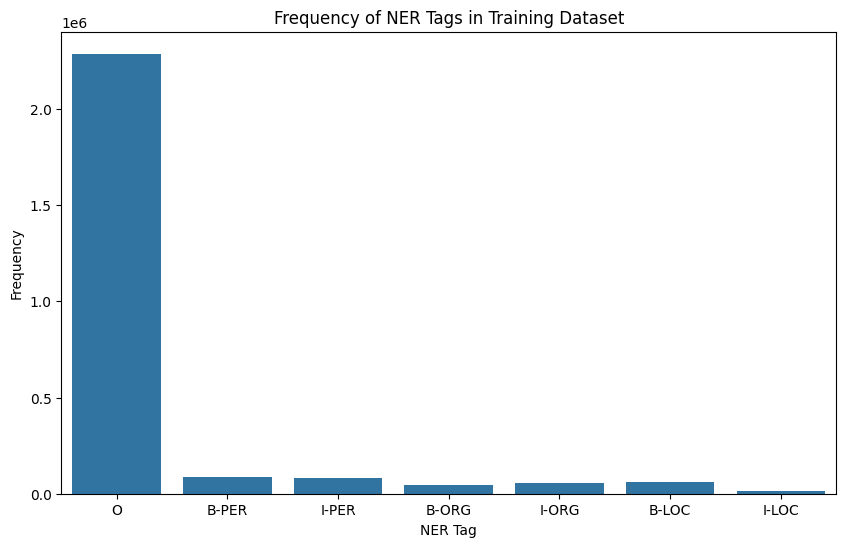

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ner_tags = [tag for sentence_tags in ds["train"]["ner_tags"] for tag in sentence_tags]
tag_counts = pd.Series(ner_tags).value_counts().sort_index()

tag_names = ds["train"].features["ner_tags"].feature.names
tag_counts.index = tag_counts.index.map(lambda x: tag_names[x])

plt.figure(figsize=(10, 6))
sns.barplot(x=tag_counts.index, y=tag_counts.values)
plt.xlabel("NER Tag")
plt.ylabel("Frequency")
plt.title("Frequency of NER Tags in Training Dataset")
plt.show()

## Examine sentence lengths

### Subtask:
Analyze the distribution of sentence lengths in terms of the number of tokens.


**Reasoning**:
Extract the 'tokens' lists from the 'train' split, calculate the length of each list, store the lengths, visualize the distribution of lengths using a histogram, and print the descriptive statistics.



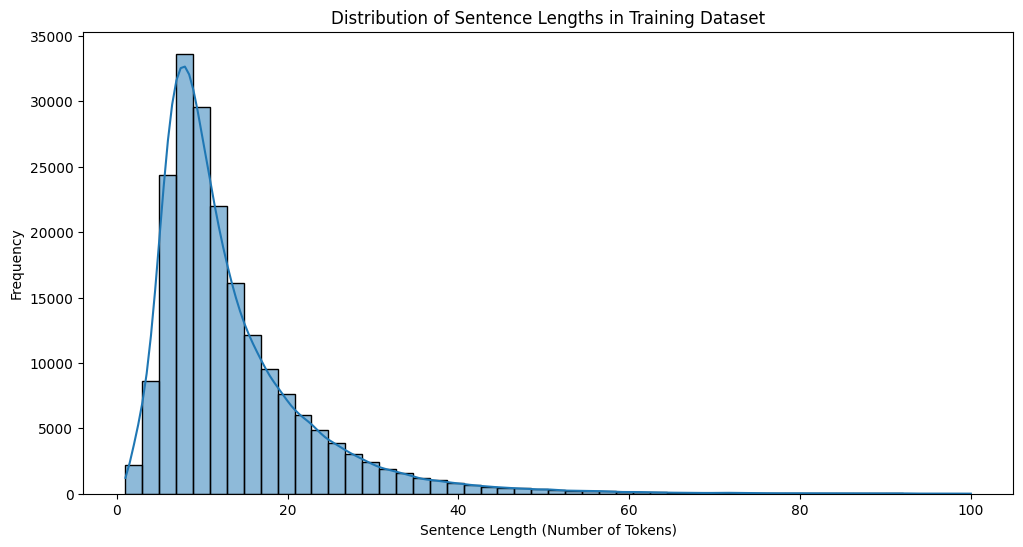

Descriptive Statistics of Sentence Lengths:


,0
count,196793.000000
mean,13.342654
std,9.518787
min,1.000000
25%,7.000000
50%,11.000000
75%,16.000000
max,100.000000


In [ ]:
sentence_lengths = [len(tokens) for tokens in ds["train"]["tokens"]]
sentence_lengths_series = pd.Series(sentence_lengths)

plt.figure(figsize=(12, 6))
sns.histplot(sentence_lengths_series, bins=50, kde=True)
plt.xlabel("Sentence Length (Number of Tokens)")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths in Training Dataset")
plt.show()

print("Descriptive Statistics of Sentence Lengths:")
display(sentence_lengths_series.describe())

## Investigate the relationship between sentence length and ner tags

### Subtask:
See if there is any correlation between sentence length and the presence of specific NER tags.


**Reasoning**:
Calculate sentence lengths and identify sentences with NER tags to prepare for plotting the relationship between sentence length and the presence of NER tags.



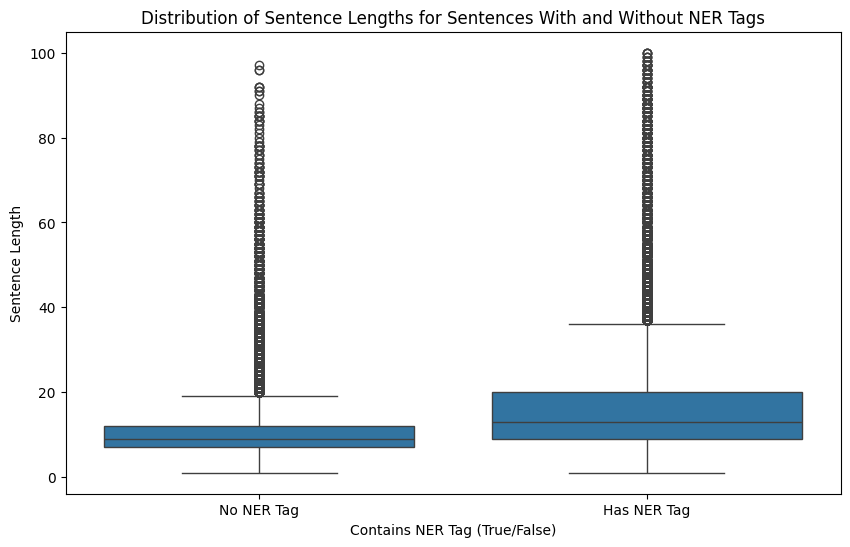

In [ ]:
sentence_lengths = [len(tokens) for tokens in ds["train"]["tokens"]]
has_ner_tag = [any(tag != 0 for tag in ner_tags) for ner_tags in ds["train"]["ner_tags"]]

sentence_data = pd.DataFrame({
    'sentence_length': sentence_lengths,
    'has_ner_tag': has_ner_tag
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='has_ner_tag', y='sentence_length', data=sentence_data)
plt.xlabel("Contains NER Tag (True/False)")
plt.ylabel("Sentence Length")
plt.title("Distribution of Sentence Lengths for Sentences With and Without NER Tags")
plt.xticks([0, 1], ['No NER Tag', 'Has NER Tag'])
plt.show()

**Reasoning**:
Visualize the distribution of sentence lengths for sentences containing specific types of NER tags compared to sentences without that specific tag to further investigate the relationship between sentence length and the presence of different NER tag types.



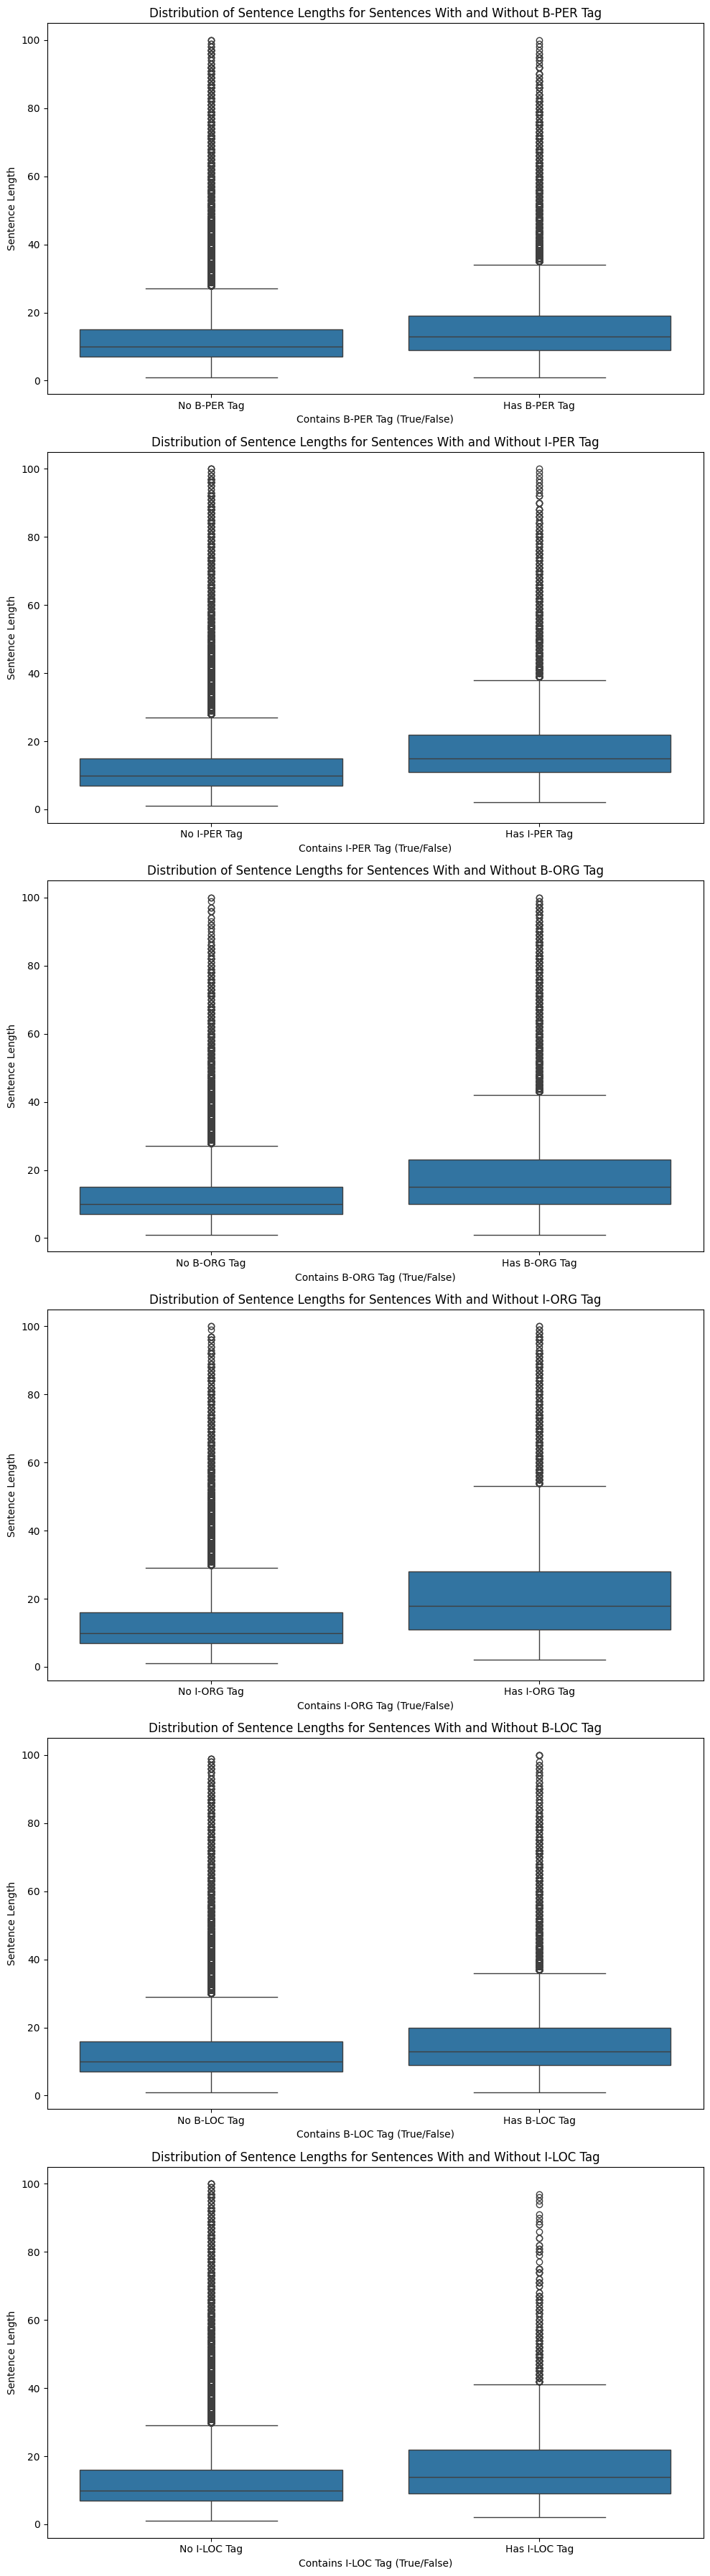

In [ ]:
ner_tag_names = ds["train"].features["ner_tags"].feature.names[1:] # Exclude 'O' tag

num_tags = len(ner_tag_names)
fig, axes = plt.subplots(nrows=num_tags, ncols=1, figsize=(10, 6 * num_tags))

for i, tag_name in enumerate(ner_tag_names):
    tag_index = ds["train"].features["ner_tags"].feature.str2int(tag_name)
    has_specific_ner_tag = [tag_index in tags for tags in ds["train"]["ner_tags"]]

    specific_tag_data = pd.DataFrame({
        'sentence_length': sentence_lengths,
        'has_specific_ner_tag': has_specific_ner_tag
    })

    sns.boxplot(x='has_specific_ner_tag', y='sentence_length', data=specific_tag_data, ax=axes[i])
    axes[i].set_xlabel(f"Contains {tag_name} Tag (True/False)")
    axes[i].set_ylabel("Sentence Length")
    axes[i].set_title(f"Distribution of Sentence Lengths for Sentences With and Without {tag_name} Tag")
    axes[i].set_xticks([0, 1], [f'No {tag_name} Tag', f'Has {tag_name} Tag'])

plt.tight_layout()
plt.show()

## Analyze the most frequent tokens

### Subtask:
Identify the most common words or tokens in the dataset.


In [ ]:
all_tokens = [token for sentence_tokens in ds["train"]["tokens"] for token in sentence_tokens]
token_counts = pd.Series(all_tokens).value_counts()
display(token_counts.head(10))

,count
।,179775
",",89307
ଓ,32922
ଏହି,29658
ଏବଂ,28352
ପାଇଁ,17639
-,14711
',13370
"""",13057
ମଧ୍ୟ,12649


## Analyze the most frequent tokens for each ner tag

### Subtask:
Identify the most common words associated with specific NER tags.


In [ ]:
token_counts_by_ner_tag = {}
tag_names = ds["train"].features["ner_tags"].feature.names

for example in ds["train"]:
    tokens = example["tokens"]
    ner_tags = example["ner_tags"]

    for token, tag_index in zip(tokens, ner_tags):
        tag_name = tag_names[tag_index]
        if tag_name != 'O':
            if tag_name not in token_counts_by_ner_tag:
                token_counts_by_ner_tag[tag_name] = {}
            if token in token_counts_by_ner_tag[tag_name]:
                token_counts_by_ner_tag[tag_name][token] += 1
            else:
                token_counts_by_ner_tag[tag_name][token] = 1

**Reasoning**:
Calculate the frequency of each token within each NER tag category and display the top N most frequent tokens for each tag.



In [ ]:
n_top_tokens = 20

for tag_name, token_counts in token_counts_by_ner_tag.items():
    print(f"Top {n_top_tokens} tokens for NER tag: {tag_name}")
    sorted_tokens = sorted(token_counts.items(), key=lambda item: item[1], reverse=True)
    for token, count in sorted_tokens[:n_top_tokens]:
        print(f"- {token}: {count}")
    print("-" * 30)

Top 20 tokens for NER tag: B-PER
- ଓ: 1232
- ଏହି: 841
- ଏବଂ: 685
- ସିଂହ: 539
- ମୁଖ୍ୟମନ୍ତ୍ରୀ: 500
- ପ୍ରଧାନମନ୍ତ୍ରୀ: 500
- ଫିଲ୍ମରେ: 465
- କୁମାର: 459
- ମଧ୍ୟ: 430
- ମୁଖ୍ୟ: 423
- ମନ୍ତ୍ରୀ: 417
- ନରେନ୍ଦ୍ର: 360
- ହେଲେ: 347
- ଶର୍ମା: 343
- ଶ୍ରୀ: 328
- ସହ: 316
- ପୂର୍ବତନ: 284
- ସିଂ: 275
- କପୁର: 272
- ରାଷ୍ଟ୍ରପତି: 262
------------------------------
Top 20 tokens for NER tag: B-ORG
- ଓ: 990
- ଏବଂ: 736
- ବିଜେପି: 528
- କଂଗ୍ରେସ: 505
- ଏହି: 390
- ବ୍ୟାଙ୍କ: 263
- ଭାରତୀୟ: 234
- ପାଇଁ: 228
- ମଧ୍ୟ: 194
- ମନ୍ତ୍ରଣାଳୟ: 190
- ମଧ୍ୟରେ: 178
- ବିଜେଡି: 176
- ବିକାଶ: 162
- କେନ୍ଦ୍ର: 159
- ରାଜ୍ୟ: 154
- -: 151
- ଇଣ୍ଡିଆ: 149
- ସହ: 146
- ନେଇ: 141
- ସରକାର: 141
------------------------------
Top 20 tokens for NER tag: I-PER
- ଓ: 2889
- ,: 2774
- ଏବଂ: 1755
- ସିଂହ: 758
- କୁମାର: 651
- ମନ୍ତ୍ରୀ: 506
- ଏହି: 480
- ପ୍ରମୁଖ: 433
- ': 408
- ମଧ୍ୟ: 395
- ମୁଖ୍ୟ: 384
- .: 378
- ପ୍ରଧାନମନ୍ତ୍ରୀ: 353
- ସିଂ: 347
- -: 344
- ଶର୍ମା: 342
- ସହ: 334
- ମୁଖ୍ୟମନ୍ତ୍ରୀ: 329
- କପୁର: 316
- ଖାନ୍: 315
------------------------------
Top 20 tokens for NER tag: B-LO

## Provide insights

### Subtask:
Summarize the key findings from the data analysis and EDA.

#PENDING

In [ ]:
# Dataset info
print(ds)

# Count total sentences per split
for split in ds.keys():
    print(f"{split} → {len(ds[split])} sentences")

# Count tokens per split
for split in ds.keys():
    token_count = sum(len(x["tokens"]) for x in ds[split])
    print(f"{split} → {token_count} tokens (avg {token_count/len(ds[split]):.2f} per sentence)")


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 196793
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 994
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 993
    })
})
train → 196793 sentences
test → 994 sentences
validation → 993 sentences
train → 2625741 tokens (avg 13.34 per sentence)
test → 13370 tokens (avg 13.45 per sentence)
validation → 13064 tokens (avg 13.16 per sentence)


['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
         train  validation   test
O      2286716       11523  11623
B-PER    84572         386    431
B-ORG    45647         225    229
I-PER    81625         381    404
B-LOC    59429         268    266
I-ORG    55603         248    329
I-LOC    12149          33     88


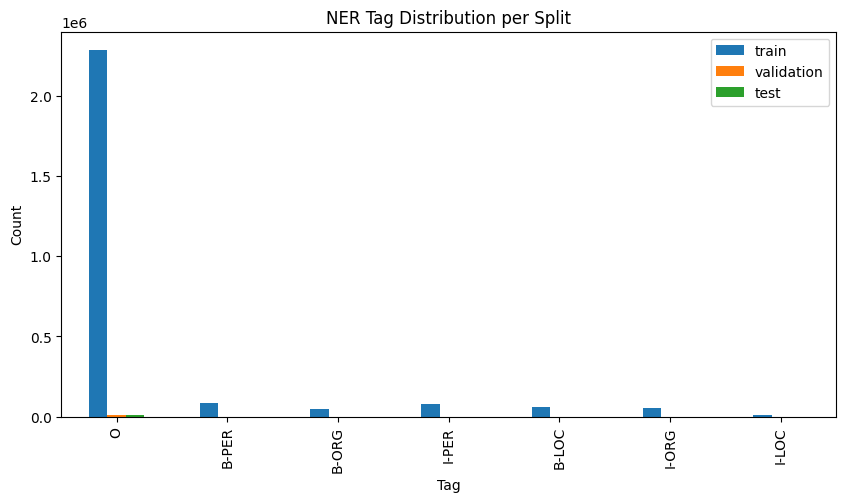

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def count_tags(split):
    counts = Counter()
    for tags in ds[split]["ner_tags"]:
        counts.update(tags)
    return counts

id2label = ds["train"].features["ner_tags"].feature.names
print(id2label)

train_counts = count_tags("train")
val_counts = count_tags("validation")
test_counts = count_tags("test")

# Convert to DataFrame for plotting
df_counts = pd.DataFrame([train_counts, val_counts, test_counts],
                         index=["train", "validation", "test"]).T
df_counts.index = [id2label[i] for i in df_counts.index]

print(df_counts)

df_counts.plot(kind="bar", figsize=(10,5))
plt.title("NER Tag Distribution per Split")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.show()

In [ ]:
# Count all tags including 'O'
all_tags = [tag for sentence_tags in ds["train"]["ner_tags"] for tag in sentence_tags]
tag_counts = Counter(all_tags)

# Map tag IDs to names using id2label
tag_names = ds["train"].features["ner_tags"].feature.names
named_tag_counts = {tag_names[tag_id]: count for tag_id, count in tag_counts.items()}

print("Counts of all NER tags (including 'O') in the training dataset:")
for tag_name, count in named_tag_counts.items():
    print(f"{tag_name}: {count}")

Counts of all NER tags (including 'O') in the training dataset:
O: 2286716
B-PER: 84572
B-ORG: 45647
I-PER: 81625
B-LOC: 59429
I-ORG: 55603
I-LOC: 12149


Sample entities: [('ଆକ୍ଷେପ', 'PER', 1), ('ସାମସଙ୍ଗ', 'ORG', 1), ('ସିଂହ', 'PER', 1), ('ପି', 'PER', 1), ('କୁମାର', 'PER', 1), ('କୋଥଜିତ୍', 'PER', 1), ('ସୁରେନ୍ଦର', 'PER', 1), ('ଚିଙ୍ଗଲେନସାନା', 'PER', 1), ('ନୀଳକାନ୍ତ ଶର୍ମା', 'PER', 2), ('ସିମରନ୍ଜିତ୍ ସିଂହ', 'PER', 2)]
Entity distribution: Counter({'PER': 84572, 'LOC': 59429, 'ORG': 45647})


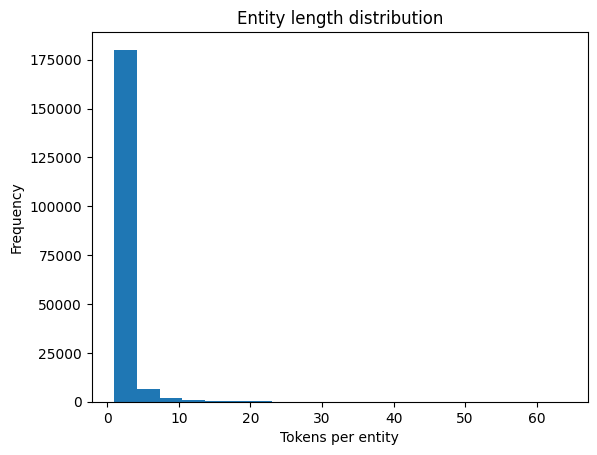

In [ ]:
# Map ids to labels
# id2label = ds["train"].features["ner_tags"].feature.names

def extract_entities(tokens, tags):
    entities = []
    current_entity = []
    current_type = None

    for token, tag_id in zip(tokens, tags):
        tag = id2label[tag_id]
        if tag.startswith("B-"):
            if current_entity:
                entities.append((" ".join(current_entity), current_type, len(current_entity)))
            current_entity = [token]
            current_type = tag.split("-")[1]
        elif tag.startswith("I-") and current_entity:
            current_entity.append(token)
        else:
            if current_entity:
                entities.append((" ".join(current_entity), current_type, len(current_entity)))
                current_entity = []
                current_type = None
    if current_entity:
        entities.append((" ".join(current_entity), current_type, len(current_entity)))
    return entities

# Extract from training set
all_entities = []
for row in ds["train"]:
    all_entities.extend(extract_entities(row["tokens"], row["ner_tags"]))

print("Sample entities:", all_entities[:10])

# Distribution
entity_counter = Counter([etype for _, etype, _ in all_entities])
print("Entity distribution:", entity_counter)

# Length distribution
lengths = [length for _, _, length in all_entities]
plt.hist(lengths, bins=20)
plt.title("Entity length distribution")
plt.xlabel("Tokens per entity")
plt.ylabel("Frequency")
plt.show()


count    196793.000000
mean          0.963693
std           1.526268
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          23.000000
dtype: float64


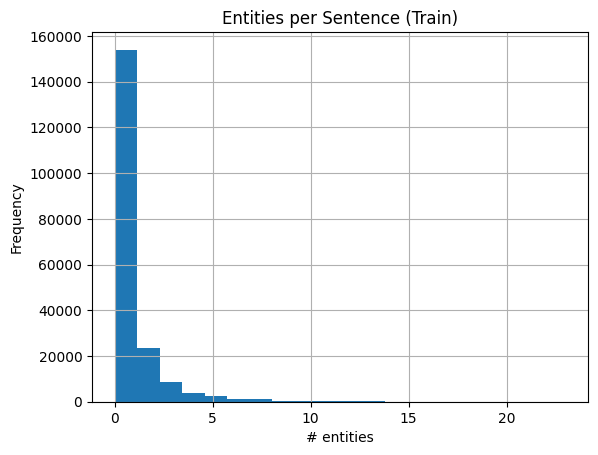

In [ ]:
def sentence_stats(split):
    num_entities = []
    for tags in ds[split]["ner_tags"]:
        count = sum(1 for t in tags if id2label[t].startswith("B-"))
        num_entities.append(count)
    return pd.Series(num_entities)

stats = sentence_stats("train")
print(stats.describe())

stats.hist(bins=20)
plt.title("Entities per Sentence (Train)")
plt.xlabel("# entities")
plt.ylabel("Frequency")
plt.show()


In [ ]:
from collections import defaultdict

# Ambiguous tokensc 961679
def ambiguous_tokens(split):
    token_labels = defaultdict(set)
    for tokens, tags in zip(ds[split]["tokens"], ds[split]["ner_tags"]):
        for tok, tag in zip(tokens, tags):
            token_labels[tok].add(id2label[tag])
    # Ambiguous = token appears with more than 1 label
    ambiguous = {tok: labs for tok, labs in token_labels.items() if len(labs) > 1}
    return ambiguous

# BIO validation
def check_bio(tokens, tags):
    for i, tag_id in enumerate(tags):
        tag = id2label[tag_id]
        if tag.startswith("I-"):
            if i == 0 or id2label[tags[i-1]][1:] != tag[1:]:
                return False
    return True

invalid = sum(not check_bio(r["tokens"], r["ner_tags"]) for r in ds["train"])
print("Invalid BIO sequences:", invalid)

# Ambiguous tokens
ambiguous = ambiguous_tokens("train")
print(f"Ambiguous tokens found: {len(ambiguous)}")
print(f"Example ambiguous tokens: {list(ambiguous.items())[:20]}")  # sample

Invalid BIO sequences: 584
Ambiguous tokens found: 31301
Example ambiguous tokens: [('କଂଗ୍ରେସ', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ପ୍ରାର୍ଥୀ', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ଆଜି', {'B-PER', 'I-PER', 'B-LOC', 'B-ORG', 'I-LOC', 'O', 'I-ORG'}), ('ପର୍ଯ୍ୟନ୍ତ', {'B-PER', 'I-PER', 'B-LOC', 'B-ORG', 'I-LOC', 'O', 'I-ORG'}), ('ଘୋଷଣା', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ନାହିଁ', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('।', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ମୋଦିଙ୍କୁ', {'B-PER', 'I-PER', 'B-LOC', 'B-ORG', 'O', 'I-ORG'}), ('ଆକ୍ଷେପ', {'O', 'B-PER'}), ('କରି', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ଗଡକରି', {'I-LOC', 'I-PER', 'O', 'B-ORG'}), ('ଏହା', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('କହିଛନ୍ତି', {'B-PER', 'I-PER', 'B-LOC', 'B-ORG', 'I-LOC', 'O', 'I-ORG'}), ('ଛାତ୍ରୀ', {'O', 'B-ORG', 'I-ORG', 'B-PER'}), ('ନେଇ', {

In [ ]:
# Rare entities
rare_entities = [e for e, c in Counter([ent for ent, _, _ in all_entities]).items() if c < 5]
print("Rare entities (appearing <5 times):", rare_entities[:20])
print("Total rare entities:", len(rare_entities))


Rare entities (appearing <5 times): ['ଆକ୍ଷେପ', 'କୋଥଜିତ୍', 'ସୁରେନ୍ଦର', 'ଚିଙ୍ଗଲେନସାନା', 'ନୀଳକାନ୍ତ ଶର୍ମା', 'ସିମରନ୍ଜିତ୍ ସିଂହ', 'ଅକ୍ଷଦୀପ', 'ମୋହନା', "ଅଂ ସାନ ସୁ କୀ ' ଙ୍କୁ ପ୍ରଧାନମନ୍ତ୍ରୀଙ୍କ ଉପହାର ପ୍ରଧାନମନ୍ତ୍ରୀ ଶ୍ରୀ ନରେନ୍ଦ୍ର ମୋଦୀ ଆଜି", 'ଙ୍କୁ ସାକ୍ଷାତ କାଳରେ ଏକ ସ୍ବତନ୍ତ୍ର ଉପହାର ଦେଇଛନ୍ତି', '1986ରେ', 'ଇନଷ୍ଟିଟ୍ୟୁଟ ଅଫ ଏଡଭାନ୍ସଡ ଷ୍ଟଡିଜରେ ଫେଲୋସିପ ପାଇଁ ସୁ କୀ ଦାଖଲ କରିଥିବା ମୌଳିକ ଗବେଷଣା ପ୍ରସ୍ତାବର ସ୍ବତନ୍ତ୍ର', 'ବଙ୍ଗୋପସାଗର', 'କୁମାର ଏବଂ ରାଜ', '୨ . ୩୫', 'ପର୍ବତ ଶୃଙ୍ଗରେ ଘୋଡ଼ାଚଢ଼ି', 'ଜଣେ ହେଲେ', 'ରାଜେନ୍ଦ୍ର ( ସ୍ୱୟମଂ ଶାସିତ ) ମହାବିଦ୍ୟାଳୟ', 'ଭୁଷନ ସଂକୃତ ମହାବିଦ୍ୟାଲୟ', 'ଓ ଚିକିତ୍ସାଳୟ']
Total rare entities: 72739


In [ ]:
# Most frequent tokens
token_counter = Counter([t for row in ds["train"] for t in row["tokens"]])
print("Most common tokens:", token_counter.most_common(20))

# Token length by entity type
import pandas as pd
df = pd.DataFrame(all_entities, columns=["entity", "etype", "length"])
print(df.groupby("etype")["length"].describe())


Most common tokens: [('।', 179775), (',', 89307), ('ଓ', 32922), ('ଏହି', 29658), ('ଏବଂ', 28352), ('ପାଇଁ', 17639), ('-', 14711), ("'", 13370), ('"', 13057), ('ମଧ୍ୟ', 12649), ('ସେ', 12307), ('ଏକ', 12186), ('କରିଛନ୍ତି', 11971), ('ପ୍ରଧାନମନ୍ତ୍ରୀ', 11617), ('ଭାରତ', 11322), ('.', 11143), (')', 10128), ('(', 10031), ('କରିଥିଲେ', 9413), ('କରିବା', 8005)]
         count      mean       std  min  25%  50%  75%   max
etype                                                       
LOC    59429.0  1.216208  1.010986  1.0  1.0  1.0  1.0  38.0
ORG    45647.0  2.199049  2.861009  1.0  1.0  1.0  2.0  64.0
PER    84572.0  1.967164  1.489674  1.0  1.0  1.0  3.0  33.0


Average Token Lengths by NER Tag (Train Set): {'O': np.float64(5.16844898973025), 'B-PER': np.float64(5.882135931513976), 'B-ORG': np.float64(5.916752470041843), 'I-PER': np.float64(5.386364471669219), 'B-LOC': np.float64(6.307745376836225), 'I-ORG': np.float64(5.61859971584267), 'I-LOC': np.float64(5.673471067577578)}
Average Token Lengths by NER Tag (Test Set): {'O': np.float64(5.135421147724339), 'B-LOC': np.float64(6.515037593984962), 'B-ORG': np.float64(5.7336244541484715), 'I-ORG': np.float64(5.4832826747720365), 'I-LOC': np.float64(5.170454545454546), 'B-PER': np.float64(6.120649651972157), 'I-PER': np.float64(5.502475247524752)}
Average Token Lengths by NER Tag (Validation Set): {'O': np.float64(5.166623275188753), 'B-LOC': np.float64(6.044776119402985), 'B-ORG': np.float64(5.768888888888889), 'I-ORG': np.float64(5.82258064516129), 'B-PER': np.float64(5.740932642487047), 'I-PER': np.float64(5.301837270341207), 'I-LOC': np.float64(7.03030303030303)}


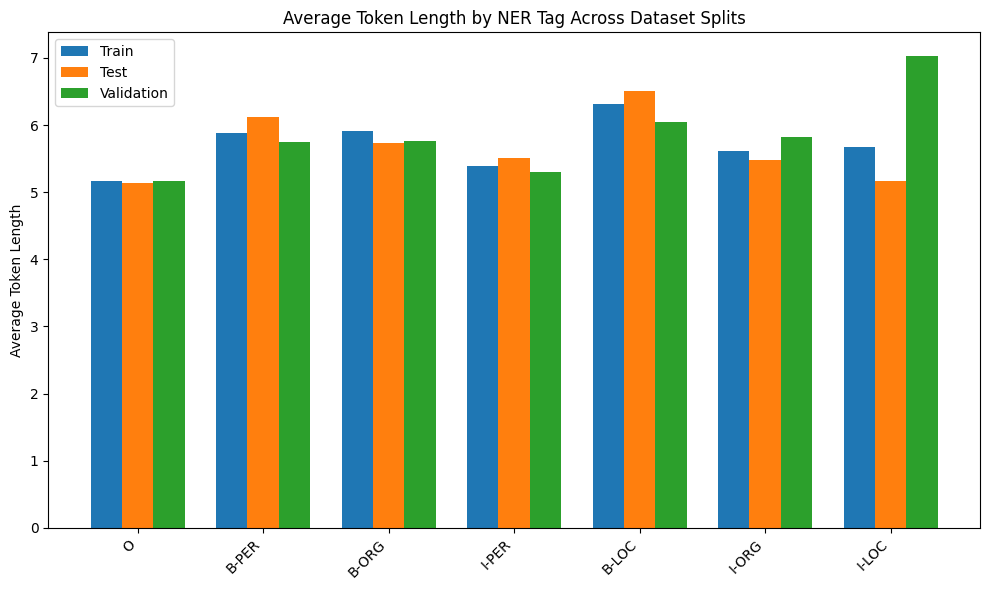

In [ ]:
import collections
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ner_tag_names = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]


def analyze_token_lengths_by_ner_tag(dataset, tag_names):
    """
    Analyzes the token lengths for each NER tag in a given dataset split.

    Args:
        dataset: A Hugging Face Dataset split (e.g., raw_dataset["train"]).
        tag_names: A list of NER tag names corresponding to the integer labels.

    Returns:
        A dictionary where keys are NER tag names and values are lists of token lengths
        associated with that tag.
    """
    token_lengths_by_tag = collections.defaultdict(list)

    for example in dataset:
        tokens = example["tokens"]
        ner_tags = example["ner_tags"]

        for token, tag_id in zip(tokens, ner_tags):
            tag_name = id2label[tag_id]
            token_lengths_by_tag[tag_name].append(len(token))

    return token_lengths_by_tag


def calculate_average_lengths(token_lengths_by_tag):
    """
    Calculates the average token length for each NER tag.

    Args:
        token_lengths_by_tag: A dictionary containing token lengths for each tag.

    Returns:
        A dictionary where keys are NER tag names and values are their average token lengths.
    """
    average_lengths = {}
    for tag, lengths in token_lengths_by_tag.items():
        if lengths:
            average_lengths[tag] = np.mean(lengths)
        else:
            average_lengths[tag] = 0
    return average_lengths


# Analyze each dataset split
train_lengths_by_tag = analyze_token_lengths_by_ner_tag(ds["train"], id2label)
test_lengths_by_tag = analyze_token_lengths_by_ner_tag(ds["test"], id2label)
validation_lengths_by_tag = analyze_token_lengths_by_ner_tag(ds["validation"], id2label)

# Calculate average token lengths
avg_train_lengths = calculate_average_lengths(train_lengths_by_tag)
avg_test_lengths = calculate_average_lengths(test_lengths_by_tag)
avg_validation_lengths = calculate_average_lengths(validation_lengths_by_tag)


# Print results
print("Average Token Lengths by NER Tag (Train Set):", avg_train_lengths)
print("Average Token Lengths by NER Tag (Test Set):", avg_test_lengths)
print("Average Token Lengths by NER Tag (Validation Set):", avg_validation_lengths)


# Optional: Visualize the average token lengths
fig, ax = plt.subplots(figsize=(10, 6))

tags = list(avg_train_lengths.keys())
train_values = [avg_train_lengths[tag] for tag in tags]
test_values = [avg_test_lengths[tag] for tag in tags]
validation_values = [avg_validation_lengths[tag] for tag in tags]

width = 0.25
x = np.arange(len(tags))

rects1 = ax.bar(x - width, train_values, width, label='Train')
rects2 = ax.bar(x, test_values, width, label='Test')
rects3 = ax.bar(x + width, validation_values, width, label='Validation')

ax.set_ylabel('Average Token Length')
ax.set_title('Average Token Length by NER Tag Across Dataset Splits')
ax.set_xticks(x)
ax.set_xticklabels(tags, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import itertools
from collections import Counter

# Co-occurrence analysis
cooccur = Counter()
for row in ds["train"]:
    ents = {etype for _, etype, _ in extract_entities(row["tokens"], row["ner_tags"])}
    for a, b in itertools.combinations(sorted(ents), 2):
        cooccur[(a, b)] += 1

print("Most common co-occurrences:", cooccur.most_common(10))

# Contextual ambiguity
contextual = {tok: labs for tok, labs in ambiguous.items() if any(l != "O" for l in labs)}
print("Tokens with multiple entity roles:", list(contextual.items())[:10])

Most common co-occurrences: [(('ORG', 'PER'), 6160), (('LOC', 'PER'), 3939), (('LOC', 'ORG'), 3065)]
Tokens with multiple entity roles: [('କଂଗ୍ରେସ', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ପ୍ରାର୍ଥୀ', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ଆଜି', {'B-PER', 'I-PER', 'B-LOC', 'B-ORG', 'I-LOC', 'O', 'I-ORG'}), ('ପର୍ଯ୍ୟନ୍ତ', {'B-PER', 'I-PER', 'B-LOC', 'B-ORG', 'I-LOC', 'O', 'I-ORG'}), ('ଘୋଷଣା', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ନାହିଁ', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('।', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'}), ('ମୋଦିଙ୍କୁ', {'B-PER', 'I-PER', 'B-LOC', 'B-ORG', 'O', 'I-ORG'}), ('ଆକ୍ଷେପ', {'O', 'B-PER'}), ('କରି', {'I-PER', 'B-LOC', 'I-ORG', 'B-ORG', 'I-LOC', 'O', 'B-PER'})]


Critical Insights from Current Analysis
#PENDING

Running class_distribution...
Completed class_distribution

Running rare_entities...
Rare entities (<5 occurrences): 79733
By type: {'PER': 43126, 'LOC': 14658, 'ORG': 21949}
Completed rare_entities

Running ambiguous_tokens...
Ambiguous tokens: 31301


/tmp/ipython-input-1257974392.py:90: UserWarning: Glyph 2837 (\N{ORIYA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1257974392.py:90: UserWarning: Matplotlib currently does not support Oriya natively.
  plt.tight_layout()
/tmp/ipython-input-1257974392.py:90: UserWarning: Glyph 2818 (\N{ORIYA SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1257974392.py:90: UserWarning: Glyph 2839 (\N{ORIYA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1257974392.py:90: UserWarning: Glyph 2893 (\N{ORIYA SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1257974392.py:90: UserWarning: Glyph 2864 (\N{ORIYA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1257974392.py:90: UserWarning: Glyph 2887 (\N{ORIYA VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1257974392.py:90: U

Completed ambiguous_tokens

Running cooccurrence_network...
Error running cooccurrence_network: name 'nx' is not defined

Running split_comparison...
Error running split_comparison: All arrays must be of the same length

All analyses attempted. Check for errors and generated files.


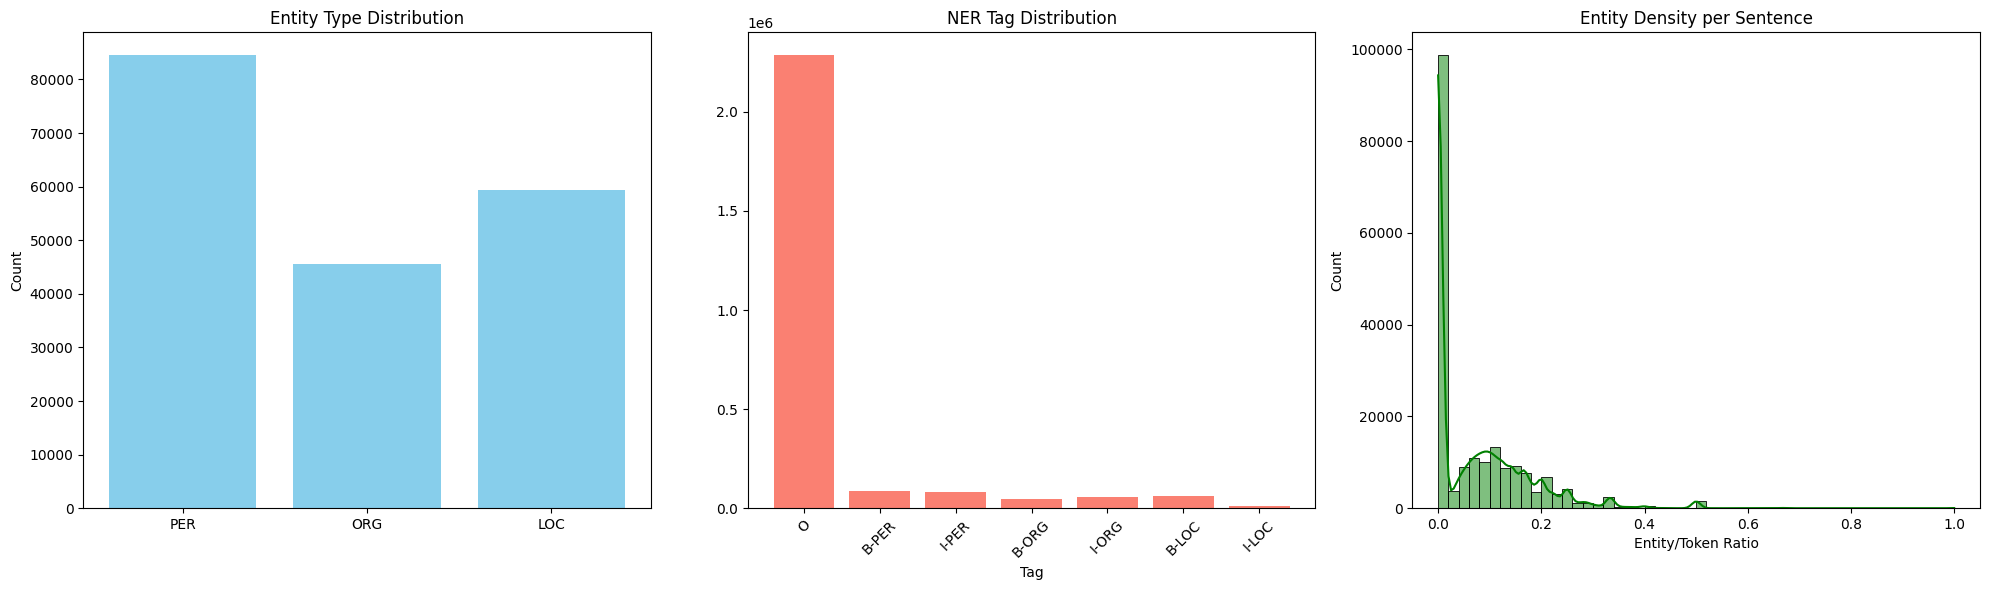

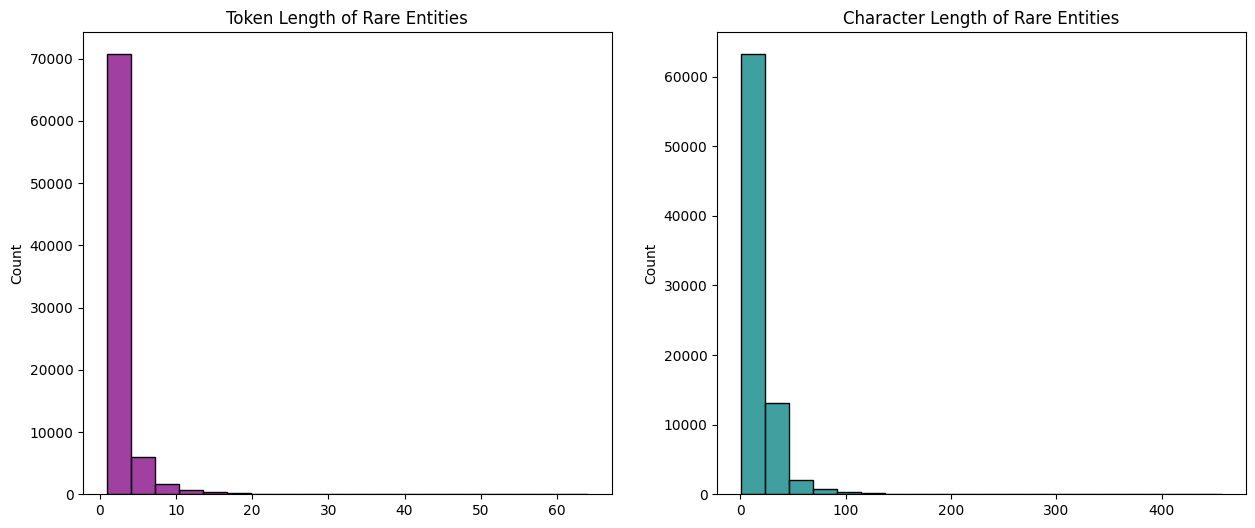

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2837 (\N{ORIYA LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Oriya natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2818 (\N{ORIYA SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2839 (\N{ORIYA LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2893 (\N{ORIYA SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packag

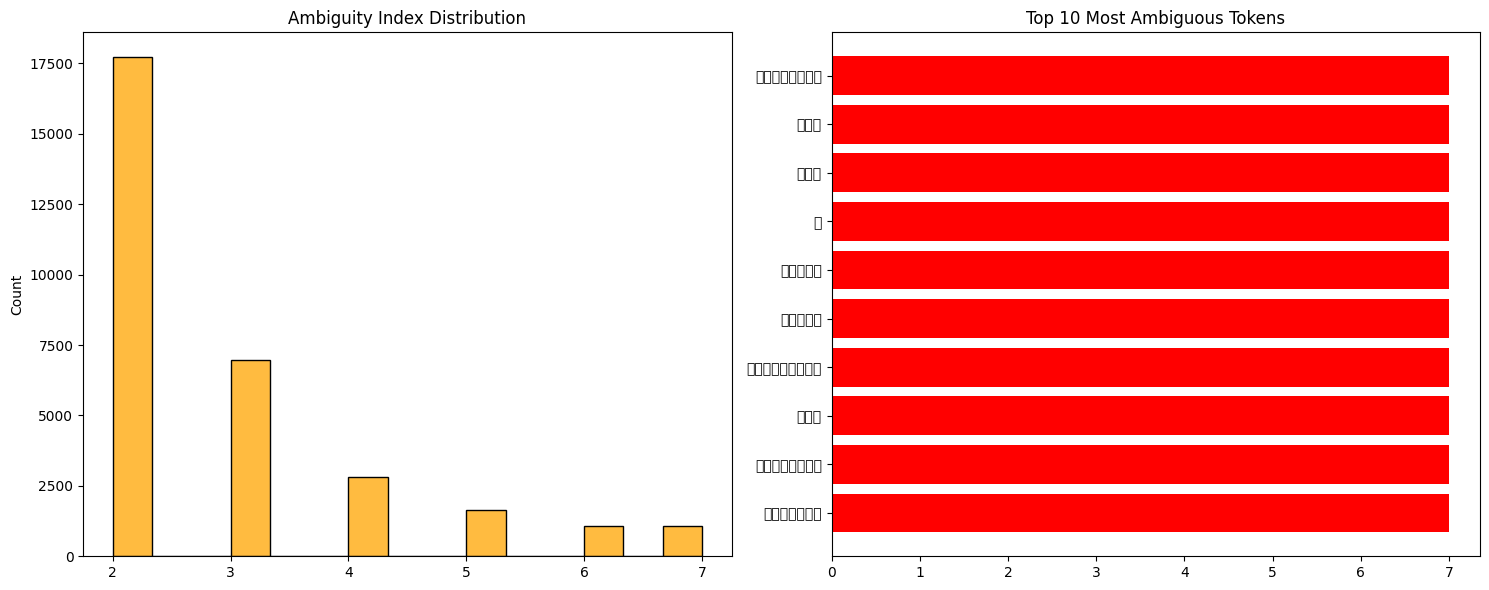

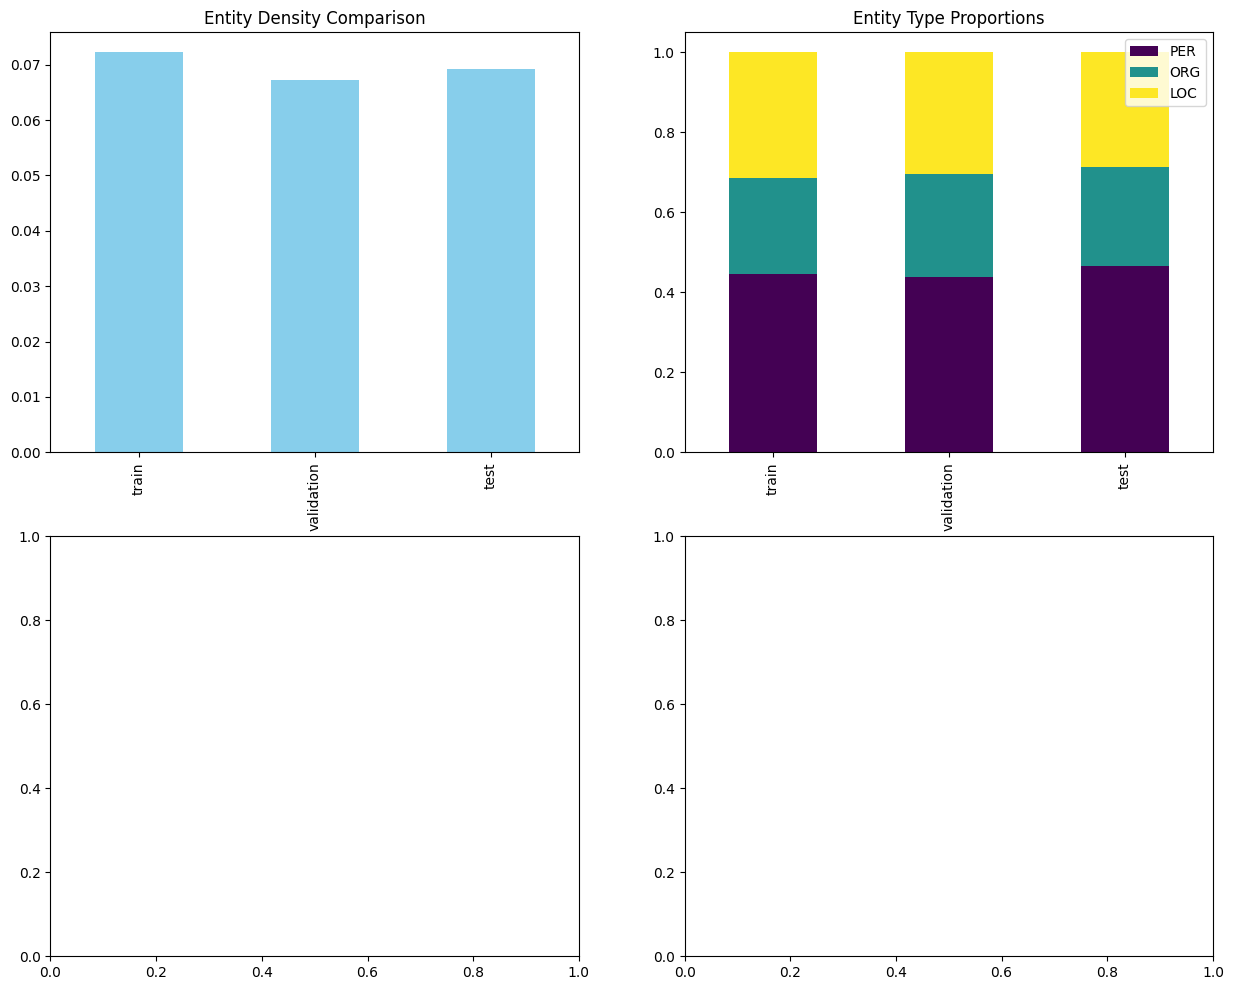

In [ ]:
# 1. Advanced Class Imbalance Analysis
def plot_class_distribution(dataset, id2label):
    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    # Entity type distribution
    all_entities_train = [ent for row in dataset['train'] for ent in extract_entities(row["tokens"], row["ner_tags"])]
    entity_counts = Counter([e[1] for e in all_entities_train])
    ax[0].bar(entity_counts.keys(), entity_counts.values(), color='skyblue')
    ax[0].set_title('Entity Type Distribution')
    ax[0].set_ylabel('Count')

    # Tag distribution (including BIO)
    tag_counts = Counter([tag for sentence_tags in dataset['train']['ner_tags'] for tag in sentence_tags])
    tags = sorted(tag_counts.keys())
    ax[1].bar([id2label[t] for t in tags], [tag_counts[t] for t in tags], color='salmon')
    ax[1].set_title('NER Tag Distribution')
    ax[1].set_xlabel('Tag')
    ax[1].tick_params(axis='x', rotation=45)


    # Sentence-level entity density
    entity_density = [len(extract_entities(sent_tokens, sent_tags))/len(sent_tokens)
                     for sent_tokens, sent_tags in zip(dataset['train']['tokens'],
                                                      dataset['train']['ner_tags'])]
    sns.histplot(entity_density, bins=50, kde=True, ax=ax[2], color='green')
    ax[2].set_title('Entity Density per Sentence')
    ax[2].set_xlabel('Entity/Token Ratio')

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=300)
    return fig

# 2. Rare Entity Analysis
def analyze_rare_entities(dataset, id2label, threshold=5):
    # Extract all entity mentions
    all_entities = []
    for row in dataset['train']:
        all_entities.extend(extract_entities(row["tokens"], row["ner_tags"]))

    entity_mentions = [(" ".join(ent[0].split()), ent[1]) for ent in all_entities] # Use split() and join() to handle multi-token entities
    entity_counts = Counter(entity_mentions)
    rare_entities = [ent for ent, count in entity_counts.items() if count < threshold]

    # Categorize rare entities
    rare_by_type = Counter([ent[1] for ent in rare_entities])
    print(f"Rare entities (<{threshold} occurrences): {len(rare_entities)}")
    print(f"By type: {dict(rare_by_type)}")

    # Plot rare entity characteristics
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Token length distribution
    token_lengths = [len(ent[0].split()) for ent in rare_entities]
    sns.histplot(token_lengths, bins=20, ax=ax[0], color='purple')
    ax[0].set_title('Token Length of Rare Entities')

    # Character length distribution
    char_lengths = [len(ent[0]) for ent in rare_entities]
    sns.histplot(char_lengths, bins=20, ax=ax[1], color='teal')
    ax[1].set_title('Character Length of Rare Entities')

    plt.savefig('rare_entities.png', dpi=300)
    return rare_entities

# 3. Ambiguous Token Analysis
def analyze_ambiguous_tokens(dataset, id2label):
    token_tags = {}
    for tokens, tags in zip(dataset['train']['tokens'], dataset['train']['ner_tags']):
        for token, tag_id in zip(tokens, tags):
            tag = id2label[tag_id]
            if token not in token_tags:
                token_tags[token] = set()
            token_tags[token].add(tag)

    ambiguous_tokens = {token: tags for token, tags in token_tags.items() if len(tags) > 1}
    print(f"Ambiguous tokens: {len(ambiguous_tokens)}")

    # Calculate ambiguity index = number of possible tags
    ambiguity_index = [len(tags) for tags in ambiguous_tokens.values()]

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    sns.histplot(ambiguity_index, bins=15, ax=ax[0], color='orange')
    ax[0].set_title('Ambiguity Index Distribution')

    # Most ambiguous tokens
    top_ambiguous = sorted(ambiguous_tokens.items(), key=lambda x: len(x[1]), reverse=True)[:10]
    ax[1].barh([t[0] for t in top_ambiguous], [len(t[1]) for t in top_ambiguous], color='red')
    ax[1].set_title('Top 10 Most Ambiguous Tokens')
    plt.tight_layout()
    plt.savefig('ambiguity_analysis.png', dpi=300)

    return ambiguous_tokens

# 4. Entity Co-occurrence Network
def plot_cooccurrence_network(dataset, id2label):
    cooccurrence = Counter()
    for row in dataset['train']:
        entities = extract_entities(row["tokens"], row["ner_tags"])
        types = [e[1] for e in entities]
        for i in range(len(types)):
            for j in range(i+1, len(types)):
                pair = tuple(sorted([types[i], types[j]]))
                cooccurrence[pair] += 1

    # Create network graph
    G = nx.Graph()
    for pair, count in cooccurrence.items():
        if pair[0] != pair[1]:  # Exclude self-loops
            G.add_edge(pair[0], pair[1], weight=count)

    # Plot
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42)
    weights = [G[u][v]['weight']/500 for u,v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif')

    plt.title('Entity Type Co-occurrence Network')
    plt.savefig('cooccurrence_network.png', dpi=300)
    return cooccurrence

# 5. Dataset Comparison Analysis
def compare_splits(dataset, id2label):
    metrics = []
    for split in ['train', 'validation', 'test']:
        data = dataset[split]
        num_sentences = len(data)
        num_tokens = sum(len(tokens) for tokens in data['tokens'])
        all_entities_split = [ent for row in data for ent in extract_entities(row["tokens"], row["ner_tags"])]
        num_entities = len(all_entities_split)
        entity_density = num_entities / num_tokens if num_tokens > 0 else 0


        # Entity type distribution
        entity_types = Counter([e[1] for e in all_entities_split])

        metrics.append({
            'split': split,
            'sentences': num_sentences,
            'tokens': num_tokens,
            'entities': num_entities,
            'entity_density': entity_density,
            **entity_types
        })

    df = pd.DataFrame(metrics).set_index('split')

    # Plot comparison
    fig, ax = plt.subplots(2, 2, figsize=(15, 12))

    # Entity density
    df['entity_density'].plot(kind='bar', ax=ax[0,0], color='skyblue')
    ax[0,0].set_title('Entity Density Comparison')

    # Entity type proportions
    entity_type_cols = [col for col in df.columns if col in ['PER', 'LOC', 'ORG']]
    if entity_type_cols:
        prop_df = df[entity_type_cols].div(df[entity_type_cols].sum(axis=1), axis=0)
        prop_df.plot(kind='bar', stacked=True, ax=ax[0,1], colormap='viridis')
        ax[0,1].set_title('Entity Type Proportions')
    else:
        ax[0,1].set_title('No PER, LOC, ORG entities found')


    # Token length distribution
    token_lengths = {}
    for split in ['train', 'validation', 'test']:
        lengths = [len(tokens) for tokens in dataset[split]['tokens']]
        token_lengths[split] = lengths

    sns.boxplot(data=pd.DataFrame(token_lengths), ax=ax[1,0])
    ax[1,0].set_title('Sentence Length Distribution')

    # Entity length distribution
    entity_lengths = {}
    for split in ['train', 'validation', 'test']:
        lengths = [len(e[0].split()) for row in dataset[split] for e in extract_entities(row['tokens'], row['ner_tags'])] # Token length of entity
        entity_lengths[split] = lengths


    sns.boxplot(data=pd.DataFrame(entity_lengths), ax=ax[1,1])
    ax[1,1].set_title('Entity Length (Tokens) Distribution')

    plt.tight_layout()
    plt.savefig('split_comparison.png', dpi=300)
    return df

# Execute all analyses
analyses = {
    'class_distribution': plot_class_distribution,
     'rare_entities': analyze_rare_entities,
    'ambiguous_tokens': analyze_ambiguous_tokens,
    'cooccurrence_network': plot_cooccurrence_network,
    # 'context_analysis': lambda dataset, id2label: analyze_token_contexts(dataset, id2label, token="আন্তর্জাতিক"),
    'split_comparison': compare_splits
}

results = {}
id2label = ds["train"].features["ner_tags"].feature.names
for name, func in analyses.items():
    print(f"Running {name}...")
    try:
        results[name] = func(ds, id2label)
        print(f"Completed {name}\n")
    except Exception as e:
        print(f"Error running {name}: {e}\n")


print("All analyses attempted. Check for errors and generated files.")

#1.Rare Entity Impact Quantification

In [ ]:
# Assuming all_entities list is available from previous steps (e.g., analyze_rare_entities)
# If not, you would need to regenerate it:
# all_entities = []
# for row in ds['train']:
#     all_entities.extend(extract_entities(row["tokens"], row["ner_tags"]))

# Create a DataFrame from the all_entities list
train_df = pd.DataFrame(all_entities, columns=['entity_text', 'entity_type', 'entity_length'])

# Calculate rarity impact by entity type
entity_freq = train_df.groupby(['entity_text', 'entity_type']).size().reset_index(name='count')
type_rarity = []

for etype in ['PER', 'LOC', 'ORG']:
    type_ents = entity_freq[entity_freq.entity_type == etype]
    rare = type_ents[type_ents['count'] < 5]
    n_rare = len(rare)
    n_total = len(type_ents)

    # Avoid division by zero if no entities of this type exist
    rarity_pct = (n_rare / n_total * 100) if n_total > 0 else 0
    avg_frequency = type_ents['count'].mean() if n_total > 0 else 0

    # Statistical significance of rarity differences (requires sufficient data in both groups)
    # Skipping chi-squared test for simplicity and to avoid potential errors with small counts
    # chi2, p = np.nan, np.nan # Placeholder

    type_rarity.append({
        'type': etype,
        'rarity_pct': rarity_pct,
        'avg_frequency': avg_frequency,
        # 'rarity_chi2': chi2,
        # 'rarity_p_value': p
    })

rarity_df = pd.DataFrame(type_rarity)
print("Rarity Impact by Entity Type:")
print(rarity_df.to_markdown(index=False))

Rarity Impact by Entity Type:
| type   |   rarity_pct |   avg_frequency |
|:-------|-------------:|----------------:|
| PER    |      95.674  |         1.87621 |
| LOC    |      91.3043 |         3.70182 |
| ORG    |      94.8039 |         1.97162 |


#2. Ambiguity Contextual Analysis

In [ ]:
# Analyze ambiguous token contexts
# Update the list of ambiguous tokens to reflect the Oriya language
ambiguous_tokens = ['କଂଗ୍ରେସ', 'ପ୍ରାର୍ଥୀ', 'ଆଜି'] # Using a few examples from the previous output
contexts = []

for token in ambiguous_tokens:
    token_contexts = []
    for sentence, tags in zip(ds["train"]['tokens'], ds["train"]['ner_tags']):
        if token in sentence:
            idx = sentence.index(token)
            context_window = sentence[max(0, idx-3):min(len(sentence), idx+4)]
            context_tags = tags[max(0, idx-3):min(len(tags), idx+4)]
            token_contexts.append((' '.join(context_window), context_tags))
    contexts.append((token, token_contexts))

# Topic modeling of ambiguous contexts
for token, token_contexts in contexts:
    vectorizer = CountVectorizer(max_df=0.95, min_df=2)
    X = vectorizer.fit_transform([ctx[0] for ctx in token_contexts])
    lda = LatentDirichletAllocation(n_components=3)
    lda.fit(X)

    print(f"\nAmbiguity Resolution Topics for '{token}':")
    for idx, topic in enumerate(lda.components_):
        print(f"Topic #{idx+1}:")
        print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-5:]])

NameError: name 'ds' is not defined